# ConvexHull vs Pareto — semiring exploration

Goal: play with two multi-objective semirings side by side, see when each
one is closed, and where they disagree.

- **ConvexHull**: elements are convex hulls of 2D points. `+` is hull-of-union,
  `*` is Minkowski sum. `star` is undefined (marching off to infinity).
- **Pareto** (min-convention): elements are antichains of 2D points under
  componentwise dominance. `+` is union-with-pruning, `*` is Minkowski sum
  with pruning. `star` is a fixpoint iteration that converges on non-negative
  inputs (trivially — to `one`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull as _scipy_hull

from semirings import ConvexHull, Point
from semirings.base import Semiring


## A clean Pareto-min semiring (self-contained)

The `experimental/pareto.py` sketch has a couple of bugs (duplicate points
survive pruning; `star` breaks on the empty zero). Here's a tidy version for
the notebook.

In [2]:
def pareto_min_prune(pts):
    pts = list({tuple(p) for p in pts})   # dedupe first
    return tuple(sorted(
        p for p in pts
        if not any(q[0] <= p[0] and q[1] <= p[1] and q != p for q in pts)
    ))


class Pareto(Semiring):
    """Pareto-frontier semiring, min convention, 2D."""

    def __init__(self, points):
        self.points = pareto_min_prune(points)

    def __eq__(self, other):
        return isinstance(other, Pareto) and self.points == other.points

    def __hash__(self):
        return hash(self.points)

    def __repr__(self):
        return f'Pareto({list(self.points)})'

    def __iter__(self):
        return iter(self.points)

    def __add__(self, other):
        return Pareto(list(self.points) + list(other.points))

    def __mul__(self, other):
        if self is Pareto.zero or other is Pareto.zero:
            return Pareto.zero
        return Pareto([(a[0] + b[0], a[1] + b[1])
                       for a in self.points for b in other.points])

    def star(self):
        prev = Pareto.zero
        while True:
            curr = Pareto.one + self * prev
            if curr == prev:
                return curr
            prev = curr


Pareto.zero = Pareto([])
Pareto.one  = Pareto([(0, 0)])


## A shared plotting helper

In [3]:
def plot_panel(ax, all_pts, frontier_pts, title, color='C0'):
    all_pts = np.asarray(all_pts)
    if len(all_pts):
        ax.scatter(all_pts[:, 0], all_pts[:, 1], s=35, c='gray', alpha=0.5,
                   zorder=2, label=f'candidates ({len(all_pts)})')
    F = np.asarray(frontier_pts)
    if len(F) >= 3:
        try:
            hull = _scipy_hull(F)
            verts = F[hull.vertices]
            poly = plt.Polygon(verts, closed=True, alpha=0.12,
                               facecolor=color, edgecolor='none')
            ax.add_patch(poly)
            loop = np.vstack([verts, verts[:1]])
            ax.plot(loop[:, 0], loop[:, 1], '-', color=color, lw=1.4)
        except Exception:
            pass
    if len(F):
        order = np.lexsort((F[:, 1], F[:, 0]))
        Fo = F[order]
        ax.plot(Fo[:, 0], Fo[:, 1], '-', color=color, lw=0.8, alpha=0.5)
        ax.scatter(Fo[:, 0], Fo[:, 1], s=60, c=color, edgecolor='white',
                   lw=1, zorder=3, label=f'frontier ({len(F)})')
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25, lw=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', fontsize=8, frameon=False)


## Example 1 — the README DAG, both semirings side by side

Two-step DP, three options per step. ConvexHull and Pareto should disagree:
ConvexHull keeps only vertices of the convex polygon; Pareto keeps *every*
non-dominated point, including interior kinks that are on the Pareto
staircase but inside the hull.

ConvexHull keeps: [(6, 1), (5, 3), (3, 5), (1, 6), (2, 5)]
Pareto-min keeps: [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]


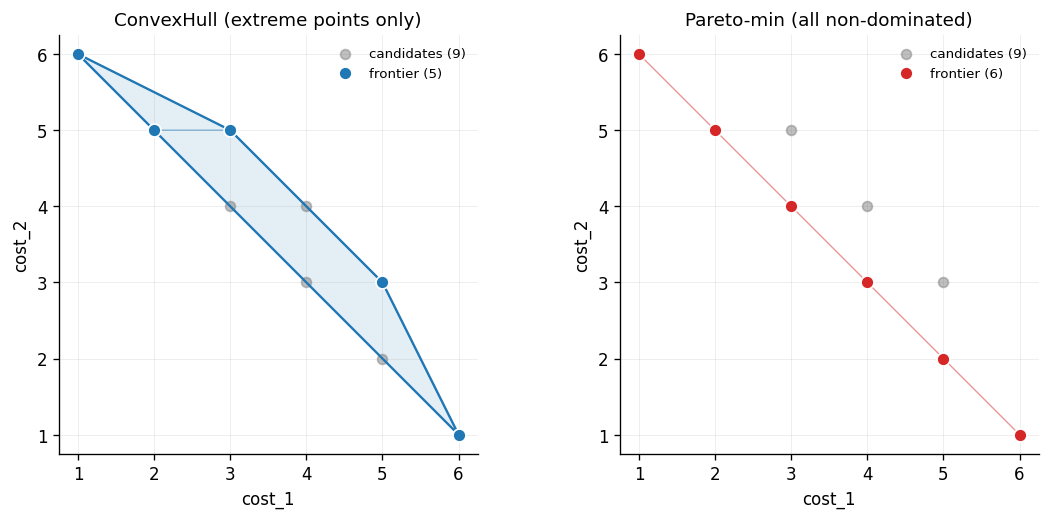

In [4]:
s1_pts = [(1, 4), (3, 3), (4, 1)]
s2_pts = [(0, 2), (2, 0), (1, 1)]

# 3x3 = 9 combined score pairs
all_combos = [(a[0]+b[0], a[1]+b[1]) for a in s1_pts for b in s2_pts]

# ConvexHull semiring
ch1 = ConvexHull([Point(*p) for p in s1_pts])
ch2 = ConvexHull([Point(*p) for p in s2_pts])
ch_frontier = [(p.x, p.y) for p in (ch1 * ch2)]

# Pareto (min) semiring
p1 = Pareto(s1_pts)
p2 = Pareto(s2_pts)
pa_frontier = list((p1 * p2).points)

print('ConvexHull keeps:', ch_frontier)
print('Pareto-min keeps:', pa_frontier)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4), dpi=120)
plot_panel(axes[0], all_combos, ch_frontier,
           'ConvexHull (extreme points only)', color='C0')
plot_panel(axes[1], all_combos, pa_frontier,
           'Pareto-min (all non-dominated)', color='C3')
for ax in axes:
    ax.set_xlabel('cost_1'); ax.set_ylabel('cost_2')
plt.tight_layout()


Note how Pareto keeps points like `(3, 4)` and `(4, 3)` that are inside
the convex hull but on the Pareto staircase — they dominate nothing, but are
dominated by no single point either. ConvexHull discards them because some
*convex combination* of hull vertices is better in every direction. Different
semirings answer different questions.

## Example 2 — Minkowski sum growth

Multiplying two hulls produces a shape shifted/enlarged by the Minkowski sum.
Watch the area grow as we chain more decisions.

final pareto: [(0, 6), (1, 4), (2, 3), (3, 2), (4, 1), (6, 0)]
final hull  : [(0, 6), (1, 4), (2, 3), (4, 1), (6, 0), (3, 3), (2, 4)]


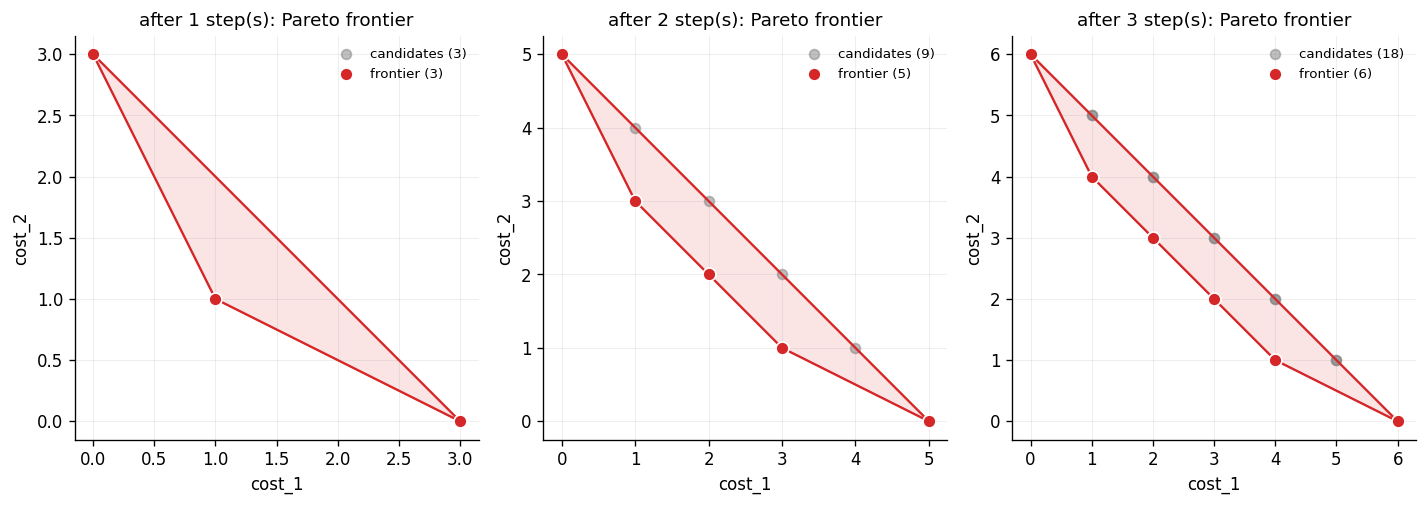

In [5]:
import functools, operator

steps = [
    [(0, 3), (3, 0), (1, 1)],
    [(0, 2), (2, 0), (1, 1)],
    [(0, 1), (1, 0)],
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=120)
running = Pareto([(0, 0)])
ch_running = ConvexHull([Point(0, 0)])

for k, pts in enumerate(steps):
    running = running * Pareto(pts)
    ch_running = ch_running * ConvexHull([Point(*p) for p in pts])

    all_so_far = functools.reduce(
        lambda A, B: [(a[0]+b[0], a[1]+b[1]) for a in A for b in B],
        steps[:k+1], [(0, 0)])

    plot_panel(axes[k], all_so_far, list(running.points),
               f'after {k+1} step(s): Pareto frontier',
               color='C3')
    axes[k].set_xlabel('cost_1'); axes[k].set_ylabel('cost_2')
plt.tight_layout()
print('final pareto:', list(running.points))
print('final hull  :', [(p.x, p.y) for p in ch_running])


## Example 3 — what happens on a cycle?

This is where the carrier-set distinction bites. `ConvexHull.star()` is
deliberately `NotImplementedError`. `Pareto.star()` *does* converge, but on
non-negative weights the answer collapses to the trivial `one = {(0, 0)}` —
consistent, closed, but uninformative.

In [6]:
# Try to star a single point in each semiring.
ch = ConvexHull([Point(2, 1)])
try:
    ch.star()
except NotImplementedError as e:
    print('ConvexHull.star() on {(2,1)}: NotImplementedError')

pa = Pareto([(2, 1)])
print('Pareto.star()   on {(2,1)}:', pa.star())
# -> Pareto([(0, 0)])  because (0,0) = one dominates every iterate (2k, k) for k >= 1


ConvexHull.star() on {(2,1)}: NotImplementedError
Pareto.star()   on {(2,1)}: Pareto([(0, 0)])


### A non-trivial Pareto star — mixed-sign weights

If points have opposing signs, iterates don't all get dominated by the
origin, and `star` diverges. The intermediate case — points with one
non-negative and one non-positive coord — is where things get interesting.
For the fixpoint to actually stabilize, the cycle has to eventually produce
iterates that *are* dominated by a fixed frontier.

  after 1 iter(s): frontier size =  3  bbox = -1..+1 x -1..+1
  after 2 iter(s): frontier size =  5  bbox = -2..+2 x -2..+2
  after 3 iter(s): frontier size =  7  bbox = -3..+3 x -3..+3
  after 4 iter(s): frontier size =  9  bbox = -4..+4 x -4..+4
  after 5 iter(s): frontier size = 11  bbox = -5..+5 x -5..+5
  after 6 iter(s): frontier size = 13  bbox = -6..+6 x -6..+6
  after 7 iter(s): frontier size = 15  bbox = -7..+7 x -7..+7
  after 8 iter(s): frontier size = 17  bbox = -8..+8 x -8..+8

Not converging: frontier keeps widening along (+1, -1) and (-1, +1) rays.
Star is undefined here — a genuine open-set semiring element.


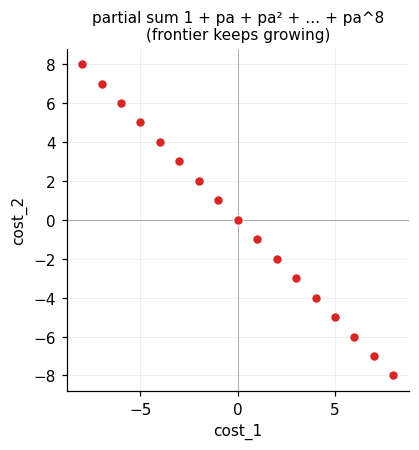

In [7]:
# A cycle with two points: one 'cheap in x, expensive in y', the other vice
# versa. Naively you'd hope iteration stabilizes; in fact iterates spread
# outward indefinitely along the anti-diagonal, so the fixpoint never settles.
pa = Pareto([(1, -1), (-1, 1)])

x = Pareto.one
MAX_ITER = 8
partial_frontier = set()
for k in range(1, MAX_ITER + 1):
    x = x * pa                                 # x = pa^k
    cum = Pareto.one
    xi = Pareto.one
    for _ in range(k):
        xi = xi * pa
        cum = cum + xi
    # report the frontier of 1 + pa + pa^2 + ... + pa^k so far
    print(f'  after {k} iter(s): frontier size = {len(cum.points):2d}  '
          f'bbox = {min(p[0] for p in cum.points):+d}..{max(p[0] for p in cum.points):+d} '
          f'x {min(p[1] for p in cum.points):+d}..{max(p[1] for p in cum.points):+d}')
    partial_frontier = set(cum.points)

print('\nNot converging: frontier keeps widening along (+1, -1) and (-1, +1) rays.')
print('Star is undefined here — a genuine open-set semiring element.')

# Visualize the partial frontier for intuition.
fig, ax = plt.subplots(figsize=(4.8, 4.2), dpi=110)
F = np.array(sorted(partial_frontier))
ax.scatter(F[:, 0], F[:, 1], s=40, c='C3', edgecolor='white', lw=0.8, zorder=3)
ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
ax.set_aspect('equal'); ax.grid(alpha=0.25, lw=0.5)
ax.set_title(f'partial sum 1 + pa + pa² + … + pa^{MAX_ITER}\n(frontier keeps growing)', fontsize=10)
ax.set_xlabel('cost_1'); ax.set_ylabel('cost_2')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()


## Example 4 — apply to a small DAG (WeightedGraph interop)

`WeightedGraph` is itself a semiring; we can give it a `Pareto` WeightType.
Let's encode a small Pareto shortest-paths problem: a diamond DAG with two
parallel paths, each with different (cost_1, cost_2) tradeoffs.

In [8]:
from semirings import WeightedGraph

g = WeightedGraph(Pareto)
# two parallel s -> t paths, each with distinct tradeoffs
g['s', 'a'] = Pareto([(3, 1)])
g['a', 't'] = Pareto([(0, 4)])
g['s', 'b'] = Pareto([(1, 3)])
g['b', 't'] = Pareto([(4, 0)])

# star = reflexive, transitive closure — on a DAG, star is the same as
# summing over all paths, which is well-defined here.
closure = g.star()
print('s -> t pareto frontier:', list(closure['s', 't'].points))


s -> t pareto frontier: [(3, 5), (5, 3)]


## Takeaways

- **DAGs, both work.** ConvexHull answers "which derivations are optimal
  under *some linear combination* of the two objectives?" Pareto answers
  "which derivations are not dominated by any other single derivation?"
  Pareto is always a superset of the ConvexHull frontier.
- **Cycles, neither shines.** ConvexHull isn't closed at all. Pareto
  converges on non-negative inputs but the answer collapses to `one`.
- The interesting closed regime for Pareto is **mixed-sign** coordinates,
  where the cycle has to "pay back" in one dimension what it gains in
  another — and even there, you need the iteration to actually reach a
  fixed antichain rather than drift outward indefinitely.